In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

from typing import Optional, overload
from itertools import product
from datetime import datetime
from copy import deepcopy
import os

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("Imports loaded.")

Using device: cuda
Imports loaded.


In [ ]:
GAMMA = 1.4
X_START, X_THROAT, X_LENGTH = 0.0, 0.5, 1.0
X_SHOCK_REF = 0.75  # reference/expected shock location
x_shock = 0.5  # initial guess, updated after shock detection

# pseudo-time horizon: run long enough that transient has died out
T_STEADY = 5.0  # evaluate steady state at this pseudo-time
T_MAX = T_STEADY  # domain upper bound in t

BD_DELTA = 1e-5  # mask width for inlet/exit/IC point selection
EVAL_PRED_POINTS = 2000  # number of points to evaluate the final solution

# ── shock detection hyper-parameters ──────────────────────────────────────────
SHOCK_DET_POINTS = 2000
SHOCK_DET_ADAM_EPOCHS = 5_000
SHOCK_DET_LBFGS_EPOCHS = 500
SHOCK_DET_ADAM_LR = 1e-3
SHOCK_DET_RESAMPLE_EVERY = 200
SHOCK_DET_PRINT_EVERY = 500
SHOCK_DET_GRAD_CLIP = 1.0
SHOCK_DET_BC_WEIGHT = 10.0
SHOCK_FORMATION_TOL = 1e-1

# ── dual-network hyper-parameters ─────────────────────────────────────────────
DUAL_NET_POINTS = 1000
DUAL_NET_TIME_SAMPLES = 200
DUAL_NET_ADAM_EPOCHS = 8_000
DUAL_NET_LBFGS_EPOCHS = 500
DUAL_NET_ADAM_LR = 1e-3
DUAL_NET_SHOCK_LR = 1e-4
DUAL_NET_RESAMPLE_EVERY = 200
DUAL_NET_PRINT_EVERY = 500
DUAL_NET_GRAD_CLIP = 1.0
DUAL_NET_BC_WEIGHT = 10.0
DUAL_NET_INTERFACE_WEIGHT = 10.0
DUAL_NET_SHOCK_PRIOR_WEIGHT = 5.0

REMESH_EVERY = 1_000  # re-mesh every this many epochs during dual-net training
REMESH_SHIFT_TOL = 1e-3

SHOCK_DET_MODEL_NAME = "shock_det_model"
DUAL_NET_PRE_MODEL_NAME = "dual_net_pre_model"
DUAL_NET_POST_MODEL_NAME = "dual_net_post_model"
INTERFACE_MODEL_NAME = "interface_model"


@overload
def get_area(x: float) -> float: ...
@overload
def get_area(x: torch.Tensor) -> torch.Tensor: ...
def get_area(x):
    return 1.0 + 2.2 * (x - X_THROAT) ** 2.0


@overload
def get_d_area(x: float) -> float: ...
@overload
def get_d_area(x: torch.Tensor) -> torch.Tensor: ...
def get_d_area(x):
    return 4.4 * (x - X_THROAT)


print("Constants defined.")

Constants defined.


In [ ]:
class ReferenceCSV:
    DEFAULT_FILENAME = "/kaggle/input/datasets/prantikdasiitmds/area-mach-number-ref-csv/area-mach-number-reference.csv"

    def __init__(self, filename: Optional[str] = None):
        filename = filename or self.DEFAULT_FILENAME
        self.reference = pd.read_csv(filename)
        self.subsonic = self.reference[self.reference["M"] < 1.0].sort_values("A")
        self.supersonic = self.reference[self.reference["M"] >= 1.0].sort_values("A")

    def get_values_from_csv(self):
        points = torch.linspace(0, 1, 1000, device=device)[:, None].requires_grad_(True)
        M_sup, M_sub, p_sup, p_sub, t_sup, t_sub, rho_sup, rho_sub = map(
            lambda x: self.get_reference(points, x[0], x[1]),
            product(["M", "p", "T", "rho"], ["supersonic", "subsonic"]),
        )
        return points, M_sup, M_sub, p_sup, p_sub, t_sup, t_sub, rho_sup, rho_sub

    def get_reference(self, x_t: torch.Tensor, to: str, branch_name: str):
        area_ratio = get_area(x_t).detach().cpu().numpy()
        branch = self.supersonic if branch_name == "supersonic" else self.subsonic
        return scipy.interpolate.interp1d(
            branch["A"],
            self.get_branch_data(to, branch),
            bounds_error=False,
            fill_value=(branch[to].iloc[0], branch[to].iloc[-1]),
        )(area_ratio).squeeze()

    @staticmethod
    def get_branch_data(to: str, branch: pd.DataFrame):
        return branch[to] if to not in ["p", "rho", "T"] else 1 / branch[to]


def _bisection_for_mach_no(a: float, supersonic: bool) -> float:
    def func(M):
        t = 1.0 + (GAMMA - 1.0) / 2.0 * M**2.0
        expo = (GAMMA + 1.0) / (2.0 * (GAMMA - 1.0))
        return (1.0 / M) * (2.0 / (GAMMA + 1.0) * t) ** expo - a

    low, high = (1.0 + BD_DELTA, 10.0) if supersonic else (BD_DELTA, 1.0 - BD_DELTA)
    for _ in range(300):
        mid = (low + high) / 2
        if func(mid) * func(low) < 0:
            high = mid
        else:
            low = mid
    return (low + high) / 2


def get_back_pressure_from_shock(x_shock_loc: float) -> float:
    A_shock = get_area(x_shock_loc)
    M_pre = _bisection_for_mach_no(A_shock, supersonic=True)
    A_exit = get_area(X_LENGTH)
    M_exit = _bisection_for_mach_no(A_exit, supersonic=False)
    p0e_by_p0shock = (
        (((GAMMA + 1.0) * M_pre**2.0) / (2.0 + (GAMMA - 1.0) * M_pre**2.0))
        ** (GAMMA / (GAMMA - 1.0))
    ) * (
        ((GAMMA + 1.0) / (2.0 * GAMMA * M_pre**2.0 - GAMMA + 1.0))
        ** (1.0 / (GAMMA - 1.0))
    )
    return p0e_by_p0shock * (1.0 + (GAMMA - 1.0) / 2.0 * M_exit**2.0) ** (
        -GAMMA / (GAMMA - 1.0)
    )


def get_inlet_mach() -> float:
    return _bisection_for_mach_no(get_area(X_START), supersonic=False)


P_EXIT = get_back_pressure_from_shock(X_SHOCK_REF)
_M_INLET = get_inlet_mach()
_T_INLET = 1.0 / (1.0 + (GAMMA - 1.0) / 2.0 * _M_INLET**2.0)  # T0=1
U_INLET = _M_INLET * np.sqrt(GAMMA * _T_INLET)

print(f"P_EXIT={P_EXIT:.4f}  M_INLET={_M_INLET:.4f}  U_INLET={U_INLET:.4f}")
print("Reference data loaded.")

P_EXIT=0.8429  M_INLET=0.4129  U_INLET=0.4804
Reference data loaded.


In [ ]:
class UnsteadyNet(nn.Module):
    """
    (x, t) -> (rho, u, P, T)
    """

    INPUT = 2
    OUTPUT = 4

    def __init__(self, hid_dim: int = 128, num_hidden: int = 3):
        super().__init__()
        layers = [nn.Linear(self.INPUT, hid_dim), nn.Tanh()]
        for _ in range(num_hidden):
            layers += [nn.Linear(hid_dim, hid_dim), nn.Tanh()]
        layers += [nn.Linear(hid_dim, self.OUTPUT)]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="tanh")
                nn.init.zeros_(m.bias)

    def forward(self, xt: torch.Tensor):
        out = self.net(xt)
        rho_raw, u_raw, p_raw, T_raw = (
            out[:, 0:1],
            out[:, 1:2],
            out[:, 2:3],
            out[:, 3:4],
        )

        rho = nn.functional.softplus(rho_raw + 1.0)
        P = nn.functional.softplus(p_raw + 1.0)
        T = nn.functional.softplus(T_raw + 1.0)

        return torch.cat([rho, u_raw, P, T], dim=1)


print("UnsteadyNet defined.")

UnsteadyNet defined.


In [ ]:
def sample_points(
    x_low: float,
    x_high: float,
    t_low: float = 0.0,
    t_high: float = T_MAX,
    n: int = SHOCK_DET_POINTS,
    ic_frac: float = 0.05,
    bc_frac: float = 0.05,
) -> torch.Tensor:
    n_ic = max(1, int(n * ic_frac))
    n_bc = max(1, int(n * bc_frac))
    n_int = n - 2 * n_bc - n_ic

    # interior
    x_int = torch.rand(n_int, 1, device=device) * (x_high - x_low) + x_low
    t_int = torch.rand(n_int, 1, device=device) * (t_high - t_low) + t_low

    # inlet BC  (x = x_low, t ∈ [t_low, t_high])
    x_in = torch.full((n_bc, 1), x_low, device=device)
    t_in = torch.rand(n_bc, 1, device=device) * (t_high - t_low) + t_low

    # outlet BC (x = x_high, t ∈ [t_low, t_high])
    x_out = torch.full((n_bc, 1), x_high, device=device)
    t_out = torch.rand(n_bc, 1, device=device) * (t_high - t_low) + t_low

    # IC (t = 0, x ∈ [x_low, x_high])
    x_ic = torch.rand(n_ic, 1, device=device) * (x_high - x_low) + x_low
    t_ic = torch.zeros(n_ic, 1, device=device)

    xt = torch.cat(
        [
            torch.cat([x_int, t_int], dim=1),
            torch.cat([x_in, t_in], dim=1),
            torch.cat([x_out, t_out], dim=1),
            torch.cat([x_ic, t_ic], dim=1),
        ],
        dim=0,
    )

    idx = torch.randperm(xt.shape[0], device=device)
    return xt[idx].requires_grad_(True)


print("Point sampler defined.")

Point sampler defined.


In [ ]:
def _grad(f: torch.Tensor, xt: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    g = torch.autograd.grad(f.sum(), xt, create_graph=True)[0]
    return g[:, 0:1], g[:, 1:2]


class UnsteadyLoss:
    @staticmethod
    def pde(model: UnsteadyNet, xt: torch.Tensor):
        """
        - A * drho/dt - A * u * drho/dx - A * rho * du/dx - rho * u * dA/dx = 0
        - A * (rho * (du/dt + u * du/dx) + dP/dx) = 0
        - rho * A * (dT/dt + u * dT/dx) + (GAMMA - 1) * P * (A * du/dx + dA/dx * u) = 0
        - P - rho * T = 0
        """
        out = model(xt)
        rho, u, P, T = out[:, 0:1], out[:, 1:2], out[:, 2:3], out[:, 3:4]
        x = xt[:, 0:1]
        A, A_x = get_area(x), get_d_area(x)

        rho_x, rho_t = _grad(rho, xt)
        u_x, u_t = _grad(u, xt)
        P_x, _ = _grad(P, xt)
        T_x, T_t = _grad(T, xt)

        mass = A * rho_t + A * u * rho_x + A * rho * u_x + rho * u * A_x
        momentum = A * (rho * (u_t + u * u_x) + P_x)
        energy = rho * A * (T_t + u * T_x) + (GAMMA - 1.0) * P * (A * u_x + A_x * u)
        ideal = P - rho * T

        return torch.cat([mass, momentum, energy, ideal], dim=1)

    @staticmethod
    def bc(model: UnsteadyNet, xt: torch.Tensor):
        """
        Soft BCs — all boundaries enforced as MSE penalties.
        Returns scalar.

        Inlet  (x≈0):  rho=1, u=U_INLET, P=1, T=1
        Outlet (x≈1):  P=P_EXIT
        IC     (t≈0):  rho=1, u=0, P=1, T=1
        """
        out = model(xt)
        rho, u, P, T = out[:, 0], out[:, 1], out[:, 2], out[:, 3]
        x, t = xt[:, 0], xt[:, 1]

        zero = torch.tensor(0.0, device=device)

        # inlet x≈0
        in_mask = x < BD_DELTA
        inlet_loss = (
            (
                (rho[in_mask] - 1.0).pow(2).mean()
                + (u[in_mask] - U_INLET).pow(2).mean()
                + (P[in_mask] - 1.0).pow(2).mean()
                + (T[in_mask] - 1.0).pow(2).mean()
            )
            if in_mask.any()
            else zero
        )

        # outlet x≈1
        out_mask = x > 1.0 - BD_DELTA
        outlet_loss = ((P[out_mask] - P_EXIT).pow(2).mean()) if out_mask.any() else zero

        # IC at t=0
        ic_mask = t < BD_DELTA
        ic_loss = (
            (
                (rho[ic_mask] - 1.0).pow(2).mean()
                + (u[ic_mask] - 0.0).pow(2).mean()
                + (P[ic_mask] - 1.0).pow(2).mean()
                + (T[ic_mask] - 1.0).pow(2).mean()
            )
            if ic_mask.any()
            else zero
        )

        return inlet_loss + outlet_loss + ic_loss

    @staticmethod
    def total(
        model: UnsteadyNet, xt: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        pde_res = UnsteadyLoss.pde(model, xt)
        pde_loss = pde_res.pow(2).mean()
        bc_loss = UnsteadyLoss.bc(model, xt)
        loss = pde_loss + SHOCK_DET_BC_WEIGHT * bc_loss
        return loss, pde_loss, bc_loss


print("UnsteadyLoss defined.")

UnsteadyLoss defined.


In [ ]:
class ModelHandler:
    SAVE_DIR = "saved_models"

    @staticmethod
    def save_path(name: str) -> str:
        os.makedirs(ModelHandler.SAVE_DIR, exist_ok=True)
        ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        return os.path.join(ModelHandler.SAVE_DIR, f"{name}.{ts}.pt")

    @staticmethod
    def save(model: nn.Module, path: str):
        torch.save(model.state_dict(), path)
        print(f"  Saved: {path}")

    @staticmethod
    def snapshot(model: nn.Module) -> dict:
        return deepcopy(model.state_dict())

    @staticmethod
    def update_best(model, loss_val, best_loss, best_snap):
        if loss_val < best_loss:
            return loss_val, ModelHandler.snapshot(model)
        return best_loss, best_snap


print("ModelHandler defined.")

ModelHandler defined.


In [ ]:
def shock_det_train(model: UnsteadyNet) -> tuple[list[tuple[float, float, float]], str]:
    history, best_loss, best_snap = [], float("inf"), {}

    # ── Adam phase ──────────────────────────────────────────────────────────
    optimizer = torch.optim.Adam(model.parameters(), lr=SHOCK_DET_ADAM_LR)
    xt = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)
    print(f"[{SHOCK_DET_MODEL_NAME}] Adam phase ({SHOCK_DET_ADAM_EPOCHS} epochs)")
    for epoch in range(SHOCK_DET_ADAM_EPOCHS):
        if epoch % SHOCK_DET_RESAMPLE_EVERY == 0:
            xt = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)

        optimizer.zero_grad()
        loss, pde_loss, bc_loss = UnsteadyLoss.total(model, xt)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), SHOCK_DET_GRAD_CLIP)
        optimizer.step()

        best_loss, best_snap = ModelHandler.update_best(
            model, loss.item(), best_loss, best_snap
        )
        history.append((pde_loss.item(), bc_loss.item(), loss.item()))

        if (epoch + 1) % SHOCK_DET_PRINT_EVERY == 0:
            print(
                f"  epoch {epoch+1:>{len(str(SHOCK_DET_ADAM_EPOCHS))}}/{SHOCK_DET_ADAM_EPOCHS}  "
                f"pde={pde_loss.item():.4e}  bc={bc_loss.item():.4e}  "
                f"total={loss.item():.4e}"
            )

    model.load_state_dict(best_snap)

    # ── L-BFGS phase ────────────────────────────────────────────────────────
    print(f"[{SHOCK_DET_MODEL_NAME}] L-BFGS phase ({SHOCK_DET_LBFGS_EPOCHS} epochs)…")
    xt_lbfgs = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)
    lbfgs = torch.optim.LBFGS(model.parameters(), line_search_fn="strong_wolfe")
    last = {}

    def closure():
        lbfgs.zero_grad()
        loss, pde_loss, bc_loss = UnsteadyLoss.total(model, xt_lbfgs)
        loss.backward()
        last["loss"] = loss.item()
        last["pde_loss"] = pde_loss.item()
        last["bc_loss"] = bc_loss.item()
        return loss

    for epoch in range(SHOCK_DET_LBFGS_EPOCHS):
        lbfgs.step(closure)
        best_loss, best_snap = ModelHandler.update_best(
            model, last["loss"], best_loss, best_snap
        )
        history.append((last["pde_loss"], last["bc_loss"], last["loss"]))
        if (epoch + 1) % max(1, SHOCK_DET_PRINT_EVERY // 5) == 0:
            print(
                f"  L-BFGS {epoch+1:>{len(str(SHOCK_DET_LBFGS_EPOCHS))}}/{SHOCK_DET_LBFGS_EPOCHS}  "
                f"pde={last['pde_loss']:.4e}  bc={last['bc_loss']:.4e}  "
                f"total={last['loss']:.4e}"
            )

    model.load_state_dict(best_snap)
    path = ModelHandler.save_path(SHOCK_DET_MODEL_NAME)
    ModelHandler.save(model, path)
    return history, path


shock_detection_model = UnsteadyNet().to(device)
shock_det_history, shock_det_path = shock_det_train(shock_detection_model)

two_phase_train defined.


In [ ]:
def predict_shock_location(model: UnsteadyNet) -> float:
    model.eval()

    x_lin = np.linspace(X_START, X_START + X_LENGTH, EVAL_PRED_POINTS)
    x_ten = torch.tensor(x_lin, dtype=torch.float32, device=device)[:, None]
    t_ten = torch.full_like(x_ten, T_STEADY)
    xt = torch.cat([x_ten, t_ten], dim=1).requires_grad_(True)
    output = model(xt)

    u = output[:, 1]
    du_dx = torch.autograd.grad(u.sum(), xt, create_graph=False)[0][:, 0]
    du_dx_np = du_dx.detach().cpu().numpy()
    du_dx_np[x_lin <= X_THROAT] = 0.0  # mask converging section

    # Mach check
    with torch.no_grad():
        out = model(xt)
        rho_n = out[:, 0].cpu().numpy()
        u_n = out[:, 1].cpu().numpy()
        P_n = out[:, 2].cpu().numpy()
    M_n = u_n / np.sqrt(GAMMA * P_n / rho_n)
    max_M_post_throat = M_n[x_lin > X_THROAT].max()

    print(f"Max M post-throat: {max_M_post_throat:.4f}")
    if max_M_post_throat < 1.0:
        print("WARNING: no transonic solution found; using X_SHOCK_REF as fallback.")
        return X_SHOCK_REF

    # Find shock as left edge of the steepest negative-slope region
    min_idx = int(np.argmin(du_dx_np))
    threshold = SHOCK_FORMATION_TOL * du_dx_np[min_idx]
    shock_idx = min_idx
    for i in range(min_idx, 0, -1):
        if du_dx_np[i] > threshold:
            shock_idx = i
            break

    loc = float(np.clip(x_lin[shock_idx], X_THROAT, X_START + X_LENGTH))
    print(f"Detected shock at x = {loc:.6f}  (reference = {X_SHOCK_REF:.4f})")
    return loc


x_shock = predict_shock_location(shock_detection_model)

Max M post-throat: 1.7025  (need >1 for transonic)
Detected shock at x = 0.820910  (reference = 0.7500)


In [ ]:
class ShockParam(nn.Module):
    def __init__(self, x: float):
        super().__init__()
        self.x_shock = nn.Parameter(torch.tensor([x], device=device))

    def clamped_x(self) -> torch.Tensor:
        return self.x_shock.clamp(X_THROAT + BD_DELTA, X_START + X_LENGTH - BD_DELTA)


class DualUnsteadyLoss:
    @staticmethod
    def _pde_single(model: UnsteadyNet, xt: torch.Tensor):
        return UnsteadyLoss.pde(model, xt)

    @staticmethod
    def _left_bc(model: UnsteadyNet, xt: torch.Tensor):
        return UnsteadyLoss.bc(model, xt)

    @staticmethod
    def _right_bc(model: UnsteadyNet, xt: torch.Tensor):
        return UnsteadyLoss.bc(model, xt)

    @staticmethod
    def interface(
        shock: ShockParam,
        net_L: UnsteadyNet,
        net_R: UnsteadyNet,
        t_pts: torch.Tensor,
    ):
        """
        moving shock with speed W = dx_s/dt:
            + rho_L*(u_L - W) = rho_R*(u_R - W)
            + rho_L*(u_L-W)^2 + P_L = rho_R*(u_R-W)^2 + P_R
            + H_L + (u_L-W)^2/2 = H_R + (u_R-W)^2/2
            - u_R > a_R
            - u_L < a_L
            - P_R < P_L
        """
        x_s = shock.clamped_x()
        x_col = x_s.detach().expand(t_pts.shape[0]).unsqueeze(1)
        t_col = t_pts.unsqueeze(1)
        xt_i = torch.cat([x_col, t_col], dim=1)

        out_L = net_L(xt_i)
        out_R = net_R(xt_i)
        rho_L, u_L, P_L = out_L[:, 0], out_L[:, 1], out_L[:, 2]
        rho_R, u_R, P_R = out_R[:, 0], out_R[:, 1], out_R[:, 2]
        A_i = get_area(x_s).expand_as(rho_L)

        H_L = GAMMA / (GAMMA - 1.0) * P_L / (rho_L + BD_DELTA)
        H_R = GAMMA / (GAMMA - 1.0) * P_R / (rho_R + BD_DELTA)

        flux_L_mass = rho_L * u_L * A_i
        flux_R_mass = rho_R * u_R * A_i
        rh_mass = (flux_L_mass - flux_R_mass).pow(2).mean()

        flux_L_mom = (rho_L * u_L**2 + P_L) * A_i
        flux_R_mom = (rho_R * u_R**2 + P_R) * A_i
        rh_mom = (flux_L_mom - flux_R_mom).pow(2).mean()

        flux_L_en = rho_L * u_L * (H_L + 0.5 * u_L**2) * A_i
        flux_R_en = rho_R * u_R * (H_R + 0.5 * u_R**2) * A_i
        rh_en = (flux_L_en - flux_R_en).pow(2).mean()

        a_L = torch.sqrt(GAMMA * P_L / (rho_L + BD_DELTA) + BD_DELTA)
        a_R = torch.sqrt(GAMMA * P_R / (rho_R + BD_DELTA) + BD_DELTA)
        sup_pre = torch.relu(a_L - u_L).pow(2).mean()
        sub_post = torch.relu(u_R - a_R).pow(2).mean()
        entropy = torch.relu(P_L - P_R).pow(2).mean()

        return rh_mass + rh_mom + rh_en + sup_pre + sub_post + entropy


print("DualUnsteadyLoss defined.")

DualUnsteadyLoss defined.


In [ ]:
def dual_network_training_loop(last_x_shock: float):
    net_L = UnsteadyNet().to(device)
    net_R = UnsteadyNet().to(device)

    net_L.load_state_dict(shock_detection_model.state_dict())
    net_R.load_state_dict(shock_detection_model.state_dict())

    shock = ShockParam(last_x_shock).to(device)

    pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
    pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

    best_L, snap_L = float("inf"), {}
    best_R, snap_R = float("inf"), {}
    best_I, snap_I = float("inf"), {}
    loss_history = []

    # ── Adam fine-tune ────────────────────────────────────────────────────
    model_params = list(net_L.parameters()) + list(net_R.parameters())
    model_opt = torch.optim.Adam(model_params, lr=DUAL_NET_ADAM_LR)
    shock_opt = torch.optim.Adam(shock.parameters(), lr=DUAL_NET_SHOCK_LR)
    print(f"Dual network Adam phase ({DUAL_NET_ADAM_EPOCHS} epochs)…")

    for epoch in range(DUAL_NET_ADAM_EPOCHS):
        if epoch % DUAL_NET_RESAMPLE_EVERY == 0:
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

        if epoch % REMESH_EVERY == 0 and epoch > 0:
            new_xs = shock.clamped_x().item()
            if abs(new_xs - last_x_shock) > REMESH_SHIFT_TOL:
                last_x_shock = new_xs
                pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
                pts_R = sample_points(
                    last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS
                )
                print(f"  Remesh at epoch {epoch}: x_shock = {last_x_shock:.6f}")

        t_interface = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
        interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior = (shock.clamped_x() - X_SHOCK_REF) ** 2

        pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L).pow(2).mean()
        pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R).pow(2).mean()

        bc_L = DualUnsteadyLoss._left_bc(net_L, pts_L)
        bc_R = DualUnsteadyLoss._right_bc(net_R, pts_R)

        loss = (
            pde_L
            + pde_R
            + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
            + DUAL_NET_INTERFACE_WEIGHT * interface
            + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
        )

        if not torch.isfinite(loss):
            if snap_L:
                net_L.load_state_dict(snap_L)
            if snap_R:
                net_R.load_state_dict(snap_R)
            if snap_I:
                shock.load_state_dict(snap_I)
            print(f"  NaN at epoch {epoch} — restored best snapshot, continuing")
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
            continue

        model_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model_params, DUAL_NET_GRAD_CLIP)
        for p in shock.parameters():
            p.grad = None
        model_opt.step()

        shock_opt.zero_grad()
        interface2 = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior2 = DUAL_NET_SHOCK_PRIOR_WEIGHT * (shock.clamped_x() - X_SHOCK_REF) ** 2
        shock_loss = DUAL_NET_INTERFACE_WEIGHT * interface2 + prior2
        shock_loss.backward()
        shock_opt.step()

        loss_history.append(
            (
                loss.item(),
                pde_L.item(),
                pde_R.item(),
                bc_L.item(),
                bc_R.item(),
                interface.item(),
                shock.clamped_x().item(),
            )
        )

        best_L, snap_L = ModelHandler.update_best(net_L, loss.item(), best_L, snap_L)
        best_R, snap_R = ModelHandler.update_best(net_R, loss.item(), best_R, snap_R)
        best_I, snap_I = ModelHandler.update_best(shock, loss.item(), best_I, snap_I)

        if (epoch + 1) % DUAL_NET_PRINT_EVERY == 0:
            xs = shock.clamped_x().item()
            with torch.no_grad():
                xt_s = torch.tensor([[xs, T_STEADY]], device=device)
                o_L = net_L(xt_s)
                o_R = net_R(xt_s)
                M_L = (o_L[0, 1] / torch.sqrt(GAMMA * o_L[0, 2] / o_L[0, 0])).item()
                M_R = (o_R[0, 1] / torch.sqrt(GAMMA * o_R[0, 2] / o_R[0, 0])).item()
            print(
                f"  epoch {epoch+1}/{DUAL_NET_ADAM_EPOCHS}  x_shock={xs:.5f}  "
                f"loss={loss.item():.4e}  "
                f"pde=({pde_L.item():.3e},{pde_R.item():.3e})  "
                f"bc=({bc_L.item():.3e},{bc_R.item():.3e})  "
                f"interface={interface.item():.3e}  "
                f"M@shock: pre={M_L:.3f}(>1) post={M_R:.3f}(<1)"
            )

    net_L.load_state_dict(snap_L)
    net_R.load_state_dict(snap_R)
    shock.load_state_dict(snap_I)

    # ── L-BFGS fine-tune ──────────────────────────────────────────────────
    print("Dual network L-BFGS phase…")
    pts_L_lbfgs = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
    pts_R_lbfgs = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
    t_interface_lbfgs = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
    last = {}

    lbfgs = torch.optim.LBFGS(
        list(net_L.parameters()) + list(net_R.parameters()) + list(shock.parameters()),
        line_search_fn="strong_wolfe",
    )

    def closure_dual():
        lbfgs.zero_grad()
        pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L_lbfgs).pow(2).mean()
        pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R_lbfgs).pow(2).mean()

        bc_L = DualUnsteadyLoss._left_bc(net_L, pts_L_lbfgs)
        bc_R = DualUnsteadyLoss._right_bc(net_R, pts_R_lbfgs)

        interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface_lbfgs)
        prior = (shock.clamped_x() - X_SHOCK_REF) ** 2

        loss = (
            pde_L
            + pde_R
            + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
            + DUAL_NET_INTERFACE_WEIGHT * interface
            + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
        )

        loss.backward()
        last["loss"] = (
            loss.item(),
            pde_L.item(),
            pde_R.item(),
            bc_L.item(),
            bc_R.item(),
            interface.item(),
            shock.clamped_x().item(),
        )

        return loss

    for epoch in range(DUAL_NET_LBFGS_EPOCHS):
        lbfgs.step(closure_dual)
        best_L, snap_L = ModelHandler.update_best(
            net_L, last["loss"][0], best_L, snap_L
        )
        best_R, snap_R = ModelHandler.update_best(
            net_R, last["loss"][0], best_R, snap_R
        )
        best_I, snap_I = ModelHandler.update_best(
            shock, last["loss"][0], best_I, snap_I
        )

        if (epoch + 1) % max(1, DUAL_NET_PRINT_EVERY // 10) == 0:
            xs = shock.clamped_x().item()
            with torch.no_grad():
                xt_s = torch.tensor([[xs, T_STEADY]], device=device)
                o_L = net_L(xt_s)
                o_R = net_R(xt_s)
                M_L = (o_L[0, 1] / torch.sqrt(GAMMA * o_L[0, 2] / o_L[0, 0])).item()
                M_R = (o_R[0, 1] / torch.sqrt(GAMMA * o_R[0, 2] / o_R[0, 0])).item()
            print(
                f"  epoch {epoch+1}/{DUAL_NET_LBFGS_EPOCHS}  x_shock={xs:.5f}  "
                f"loss={last['loss'][0]:.4e}  "
                f"pde=({last['loss'][1]:.3e},{last['loss'][2]:.3e})  "
                f"bc=({last['loss'][3]:.3e},{last['loss'][4]:.3e})  "
                f"interface={last['loss'][5]:.3e}  "
                f"M@shock: pre={M_L:.3f}(>1) post={M_R:.3f}(<1)"
            )

    path_L = ModelHandler.save_path(DUAL_NET_PRE_MODEL_NAME)
    path_R = ModelHandler.save_path(DUAL_NET_POST_MODEL_NAME)
    path_I = ModelHandler.save_path(INTERFACE_MODEL_NAME)
    ModelHandler.save(net_L, path_L)
    ModelHandler.save(net_R, path_R)
    ModelHandler.save(shock, path_I)

    return net_L, net_R, shock, loss_history, (path_L, path_R, path_I)


pre_shock_model, post_shock_model, shock_param, dual_loss_history, model_paths = (
    dual_network_training_loop(last_x_shock=x_shock)
)

Dual network Adam phase (8000 epochs)…
  epoch 500/8000  x_shock=0.81953  loss=3.5650e-01  pde=(1.156e-01,3.724e-02)  iface=1.566e-02  M@shock: pre=8.323(>1) post=0.373(<1)
  epoch 1000/8000  x_shock=0.81833  loss=2.5305e-01  pde=(8.985e-02,4.025e-02)  iface=7.041e-03  M@shock: pre=6.214(>1) post=0.405(<1)
  Remesh at epoch 1000: x_shock → 0.818328
  epoch 1500/8000  x_shock=0.81657  loss=3.3496e-01  pde=(7.333e-02,4.542e-02)  iface=1.327e-02  M@shock: pre=8.332(>1) post=0.417(<1)
  epoch 2000/8000  x_shock=0.81422  loss=4.7179e-01  pde=(7.978e-02,2.422e-02)  iface=3.278e-02  M@shock: pre=6.841(>1) post=0.419(<1)
  Remesh at epoch 2000: x_shock → 0.814218
  epoch 2500/8000  x_shock=0.81133  loss=4.7018e-01  pde=(1.015e-01,8.548e-02)  iface=1.595e-02  M@shock: pre=8.931(>1) post=0.355(<1)
  epoch 3000/8000  x_shock=0.80742  loss=2.0262e-01  pde=(7.990e-02,1.177e-02)  iface=8.159e-03  M@shock: pre=8.336(>1) post=0.383(<1)
  Remesh at epoch 3000: x_shock → 0.807418
  epoch 3500/8000  x_sh

In [ ]:
def predict_final_results():
    pre_shock_model.eval()
    post_shock_model.eval()
    shock_param.eval()

    shock_at = shock_param.clamped_x().item()
    print(f"\nFinal shock location: {shock_at:.6f}  (reference: {X_SHOCK_REF:.4f})")

    x_eval_np = np.linspace(X_START, X_START + X_LENGTH, EVAL_PRED_POINTS)
    x_ten = torch.tensor(x_eval_np, dtype=torch.float32, device=device)
    t_ten = torch.full_like(x_ten, T_STEADY)
    xt_eval = torch.stack([x_ten, t_ten], dim=1)

    with torch.no_grad():
        out_pre = pre_shock_model(xt_eval[x_eval_np < shock_at])  # type: ignore
        out_post = post_shock_model(xt_eval[x_eval_np >= shock_at])  # type: ignore

    rho_pre, u_pre, P_pre, T_pre = (
        out_pre[:, 0].cpu().numpy(),
        out_pre[:, 1].cpu().numpy(),
        out_pre[:, 2].cpu().numpy(),
        out_pre[:, 3].cpu().numpy(),
    )
    rho_post, u_post, P_post, T_post = (
        out_post[:, 0].cpu().numpy(),
        out_post[:, 1].cpu().numpy(),
        out_post[:, 2].cpu().numpy(),
        out_post[:, 3].cpu().numpy(),
    )

    M_pre = u_pre / np.sqrt(GAMMA * P_pre / rho_pre)
    M_post = u_post / np.sqrt(GAMMA * P_post / rho_post)

    print(f"M at shock (pre) : {M_pre[-1]:.4f}  (expect >1)")
    print(f"M at shock (post): {M_post[0]:.4f}  (expect <1)")
    print(f"P at exit        : {P_post[-1]:.4f}  (target {P_EXIT:.4f})")

    return (
        x_eval_np,
        (rho_pre, u_pre, P_pre, T_pre, M_pre),
        (rho_post, u_post, P_post, T_post, M_post),
        shock_at,
    )


x_eval_np, pre_results, post_results, final_shock_loc = predict_final_results()


Final shock location: 0.750042  (reference: 0.7500)
M at shock (pre) : 3.8294  (expect >1)
M at shock (post): 0.4372  (expect <1)
P at exit        : 1.0594  (target 0.8429)


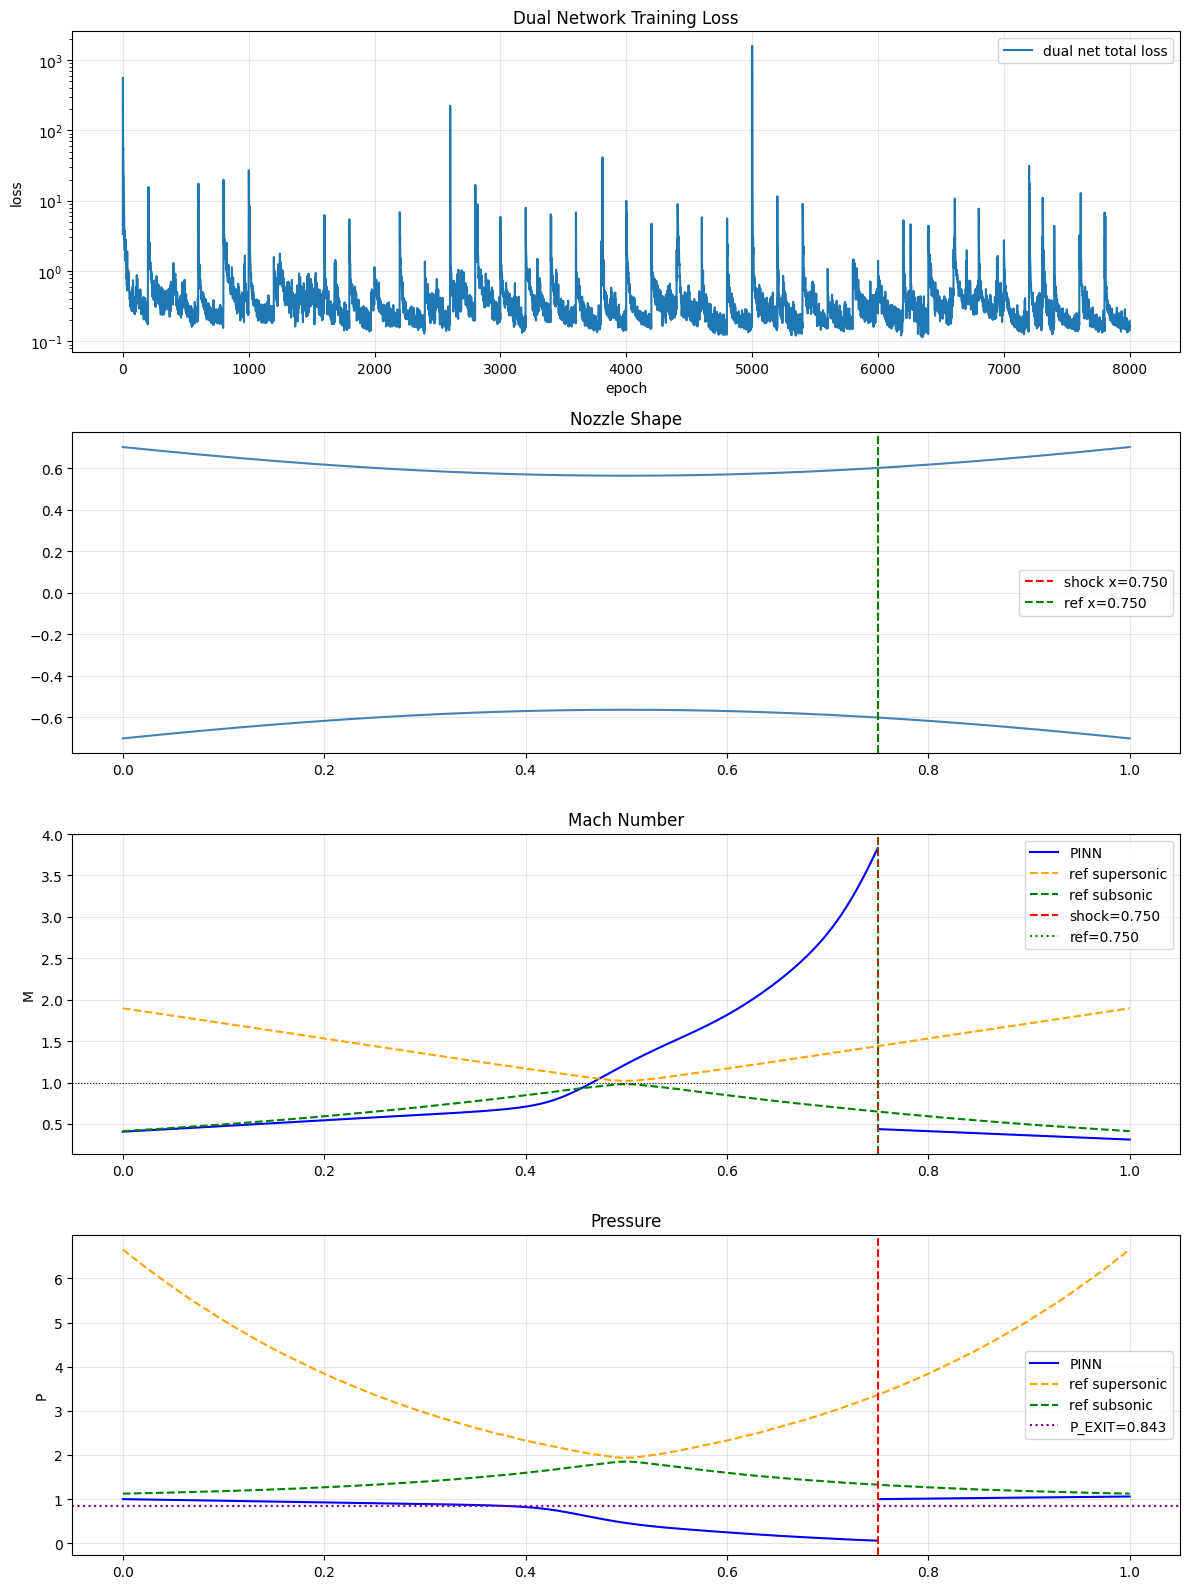

Done.


In [ ]:
reference = ReferenceCSV()
pts_ref = torch.linspace(X_START, X_START + X_LENGTH, EVAL_PRED_POINTS, device=device)
pts_ref = pts_ref[:, None].requires_grad_(True)
pts_ref_np = pts_ref.squeeze().detach().cpu().numpy()

pre_mask = x_eval_np < final_shock_loc
post_mask = x_eval_np >= final_shock_loc

(
    x_points_ref,
    M_ref_sup,
    M_ref_sub,
    p_ref_sup,
    p_ref_sub,
    t_ref_sup,
    t_ref_sub,
    rho_ref_sup,
    rho_ref_sub,
) = reference.get_values_from_csv()

fig, axes = plt.subplots(6, 1, figsize=(12, 36))

# loss history
ax = axes[0]
history_arr = np.array(dual_loss_history)
ax.plot(history_arr[:, 0], label="dual net total loss")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Dual Network Training Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# nozzle shape
ax = axes[1]
x_ref_plot_np = x_points_ref.detach().cpu().numpy()
r = np.sqrt(get_area(x_points_ref).detach().cpu().numpy() / np.pi)
ax.plot(x_ref_plot_np, r, color="steelblue")
ax.plot(x_ref_plot_np, -r, color="steelblue")
ax.axvline(final_shock_loc, color="red", ls="--", label=f"shock={final_shock_loc:.3f}")
ax.axvline(X_SHOCK_REF, color="green", ls="--", label=f"ref={X_SHOCK_REF:.3f}")
ax.set_title("Nozzle Shape")
ax.legend()
ax.grid(True, alpha=0.3)

# Mach number
ax = axes[2]
ax.plot(x_eval_np[pre_mask], pre_results[4], color="blue", label="PINN")
ax.plot(x_eval_np[post_mask], post_results[4], color="blue")
ax.plot(pts_ref_np, M_ref_sup, color="orange", ls="--", label="ref supersonic")
ax.plot(pts_ref_np, M_ref_sub, color="green", ls="--", label="ref subsonic")
ax.axvline(final_shock_loc, color="red", ls="--", label=f"shock={final_shock_loc:.3f}")
ax.axvline(X_SHOCK_REF, color="green", ls=":", label=f"ref={X_SHOCK_REF:.3f}")
ax.axhline(1.0, color="black", ls=":", lw=0.8)
ax.set_title("Mach Number")
ax.set_ylabel("M")
ax.legend()
ax.grid(True, alpha=0.3)

# Pressure
ax = axes[3]
ax.plot(x_eval_np[pre_mask], pre_results[2], color="blue", label="PINN")
ax.plot(x_eval_np[post_mask], post_results[2], color="blue")
ax.plot(pts_ref_np, p_ref_sup, color="orange", ls="--", label="ref supersonic")
ax.plot(pts_ref_np, p_ref_sub, color="green", ls="--", label="ref subsonic")
ax.axvline(final_shock_loc, color="red", ls="--", label=f"shock={final_shock_loc:.3f}")
ax.axvline(X_SHOCK_REF, color="green", ls=":", label=f"ref={X_SHOCK_REF:.3f}")
ax.axhline(P_EXIT, color="purple", ls=":", label=f"P_EXIT={P_EXIT:.3f}")
ax.set_title("Pressure")
ax.set_ylabel("P")
ax.legend()
ax.grid(True, alpha=0.3)

# Temperature
ax = axes[4]
ax.plot(x_eval_np[pre_mask], pre_results[3], color="blue", label="PINN")
ax.plot(x_eval_np[post_mask], post_results[3], color="blue")
ax.plot(pts_ref_np, t_ref_sup, color="orange", ls="--", label="ref supersonic")
ax.plot(pts_ref_np, t_ref_sub, color="green", ls="--", label="ref subsonic")
ax.axvline(final_shock_loc, color="red", ls="--", label=f"shock={final_shock_loc:.3f}")
ax.axvline(X_SHOCK_REF, color="green", ls=":", label=f"ref={X_SHOCK_REF:.3f}")
ax.set_title("Temperature")
ax.set_ylabel("T")
ax.set_xlabel("x")
ax.legend()
ax.grid(True, alpha=0.3)

# Density
ax = axes[5]
ax.plot(x_eval_np[pre_mask], pre_results[0], color="blue", label="PINN")
ax.plot(x_eval_np[post_mask], post_results[0], color="blue")
ax.plot(pts_ref_np, rho_ref_sup, color="orange", ls="--", label="ref supersonic")
ax.plot(pts_ref_np, rho_ref_sub, color="green", ls="--", label="ref subsonic")
ax.axvline(final_shock_loc, color="red", ls="--", label=f"shock={final_shock_loc:.3f}")
ax.axvline(X_SHOCK_REF, color="green", ls=":", label=f"ref={X_SHOCK_REF:.3f}")
ax.set_title("Density")
ax.set_ylabel("rho")
ax.set_xlabel("x")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cd_nozzle_addpinn_unsteady_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Done.")